# UIDAI — Capacity Pressure Score (CPS)
## Notebook 3: Visual Evidence and Observed Patterns

This notebook presents static visualizations derived from the CPS outputs.
The figures support interpretation of relative capacity pressure, volatility,
and observed trends across states during the analyzed period.


In [3]:
import pandas as pd
import numpy as np


print("Visualization libraries loaded.")
print("=" * 60)

# Load final CPS results from Notebook 1
cps_final = pd.read_csv("state_cps_final.csv")


print(f"States in CPS table: {len(cps_final)}")
print("\nPreview:")
print(cps_final.head())


state_month_combined = pd.read_csv("state_month_combined.csv")


print(f"State-month rows: {len(state_month_combined)}")

print("\nColumns available:")
print(list(state_month_combined.columns))


Visualization libraries loaded.
States in CPS table: 23

Preview:
            state  avg_update_ratio  update_volatility  avg_adult_child_skew  \
0  Andhra Pradesh        948.804362         450.416129             54.801646   
1           Assam         81.142053         101.449587             41.124326   
2           Bihar        727.041722         803.829220            405.530757   
3    Chhattisgarh        898.022249         612.459440            122.109690   
4           Delhi        414.847959         304.800686             65.611118   

   total_adult_enrolments  total_adult_updates  norm_update_intensity  \
0                    1466              1336328              72.706310   
1                   22877               928098               5.276628   
2                    9905              4434327              55.472204   
3                    1898              1557460              68.759819   
4                    2965              1021314              31.210315   

   norm_volati

In [5]:
print("— CPS COMPONENT CONTRIBUTION CHECK")
print("=" * 60)

cps_components = cps_final.copy()

cps_components['contrib_update_intensity'] = (
    0.40 * cps_components['norm_update_intensity']
)
cps_components['contrib_volatility'] = (
    0.30 * cps_components['norm_volatility']
)
cps_components['contrib_skew'] = (
    0.30 * cps_components['norm_adult_child_skew']
)
# Verify reconstruction
cps_components['reconstructed_CPS'] = (
    cps_components['contrib_update_intensity'] +
    cps_components['contrib_volatility'] +
    cps_components['contrib_skew']
)

max_diff = (cps_components['CPS'] - cps_components['reconstructed_CPS']).abs().max()

print(f"\nCPS reconstruction max error: {max_diff:.6f}")


avg_contrib = cps_components[[
    'contrib_update_intensity',
    'contrib_volatility',
    'contrib_skew'
]].mean()

print("\nAverage CPS component contribution:")
print(avg_contrib.round(2))

# Contribution percentages
total_avg = avg_contrib.sum()
print("\nAverage contribution share (%):")
print((avg_contrib / total_avg * 100).round(1))


— CPS COMPONENT CONTRIBUTION CHECK

CPS reconstruction max error: 0.000000

Average CPS component contribution:
contrib_update_intensity    15.46
contrib_volatility           9.67
contrib_skew                 7.34
dtype: float64

Average contribution share (%):
contrib_update_intensity    47.6
contrib_volatility          29.8
contrib_skew                22.6
dtype: float64


In [6]:



weight_scenarios = {
    "Base (40-30-30)": (0.40, 0.30, 0.30),
    "Intensity-heavy (50-25-25)": (0.50, 0.25, 0.25),
    "Volatility-heavy (30-40-30)": (0.30, 0.40, 0.30),
    "Skew-heavy (30-30-40)": (0.30, 0.30, 0.40)
}

rank_results = []

for label, (w1, w2, w3) in weight_scenarios.items():
    cps_temp = cps_final.copy()
    cps_temp['CPS_temp'] = (
        w1 * cps_temp['norm_update_intensity'] +
        w2 * cps_temp['norm_volatility'] +
        w3 * cps_temp['norm_adult_child_skew']
    )
    cps_temp['rank'] = cps_temp['CPS_temp'].rank(ascending=False, method='min')
    
    top5 = cps_temp.sort_values('rank').head(5)['state'].tolist()
    
    rank_results.append({
        'Scenario': label,
        'Top_5_States': top5
    })

rank_df = pd.DataFrame(rank_results)

print("\nTop 5 states under different weighting scenarios:\n")
print(rank_df.to_string(index=False))



Top 5 states under different weighting scenarios:

                   Scenario                                               Top_5_States
            Base (40-30-30)     [West Bengal, Tamil Nadu, Jharkhand, Bihar, Telangana]
 Intensity-heavy (50-25-25)     [Tamil Nadu, West Bengal, Jharkhand, Telangana, Bihar]
Volatility-heavy (30-40-30) [West Bengal, Tamil Nadu, Jharkhand, Bihar, Uttar Pradesh]
      Skew-heavy (30-30-40)     [West Bengal, Jharkhand, Tamil Nadu, Bihar, Telangana]


In [7]:

print(" ANOMALY DETECTION (UPDATE LOAD SPIKES)")


anomalies = []

for state in state_month_combined['state'].unique():
    state_data = state_month_combined[
        state_month_combined['state'] == state
    ].copy()
    
    if len(state_data) < 3:
        continue
    
    mean_ratio = state_data['adult_update_ratio'].mean()
    std_ratio = state_data['adult_update_ratio'].std()
    
    state_data['z_score'] = (
        (state_data['adult_update_ratio'] - mean_ratio) /
        (std_ratio + 0.01)
    )
    
    flagged = state_data[state_data['z_score'] > 2]
    
    for _, row in flagged.iterrows():
        anomalies.append({
            'state': state,
            'month': str(row['month']),
            'adult_update_ratio': round(row['adult_update_ratio'], 2),
            'z_score': round(row['z_score'], 2)
        })

anomaly_df = pd.DataFrame(anomalies).sort_values('z_score', ascending=False)

print(f"\nTotal anomalous state-months detected: {len(anomaly_df)}\n")

if len(anomaly_df) > 0:
    print("Top anomalous events:")
    print(anomaly_df.head(10).to_string(index=False))
else:
    print("No statistically significant anomalies detected.")


 ANOMALY DETECTION (UPDATE LOAD SPIKES)

Total anomalous state-months detected: 6

Top anomalous events:
         state   month  adult_update_ratio  z_score
       Gujarat 2025-03             1373.54     2.61
 Uttar Pradesh 2025-03             3030.89     2.46
     Karnataka 2025-03             1356.06     2.29
        Punjab 2025-09              655.20     2.23
Madhya Pradesh 2025-05              612.55     2.13
         Delhi 2025-12             1032.33     2.03


In [8]:

print(" TREND DIRECTION ANALYSIS")


from scipy.stats import linregress

trend_results = []

for state in state_month_combined['state'].unique():
    state_data = (
        state_month_combined[state_month_combined['state'] == state]
        .sort_values('month')
    )
    
    if len(state_data) < 3:
        continue
    
    x = np.arange(len(state_data))
    y = state_data['adult_update_ratio'].values
    
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    
    if abs(slope) < 10:
        trend = "Stable"
    elif slope > 0:
        trend = "Increasing"
    else:
        trend = "Decreasing"
    
    trend_results.append({
        'state': state,
        'trend': trend,
        'slope': round(slope, 2),
        'r_squared': round(r_value**2, 2)
    })

trend_df = pd.DataFrame(trend_results)

print("\nTrend direction summary:")
print(trend_df['trend'].value_counts())

print("\nSample trend results:")
print(trend_df.head(10).to_string(index=False))


 TREND DIRECTION ANALYSIS

Trend direction summary:
trend
Increasing    13
Decreasing     5
Stable         3
Name: count, dtype: int64

Sample trend results:
         state      trend  slope  r_squared
Andhra Pradesh Increasing 194.75       0.65
         Assam     Stable   2.39       0.00
         Bihar     Stable  -2.81       0.00
  Chhattisgarh Increasing 149.09       0.36
         Delhi Increasing  22.20       0.03
       Gujarat Decreasing -64.63       0.17
       Haryana Increasing  87.65       0.35
     Jharkhand Increasing 219.02       0.35
     Karnataka Decreasing -27.60       0.03
        Kerala Decreasing -20.49       0.01


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


print("Libraries loaded successfully")


Libraries loaded successfully


In [12]:
# Load CPS final table
cps_final = pd.read_csv("state_cps_final.csv")

# Load state-month combined data (from Notebook 1)
state_month_combined = pd.read_csv("state_month_combined.csv")

print("✓ Data loaded")
print(f"States in CPS table: {len(cps_final)}")
print(f"State-month rows: {len(state_month_combined)}")

print("\nPreview CPS:")
display(cps_final.head())


✓ Data loaded
States in CPS table: 23
State-month rows: 141

Preview CPS:


,state,avg_update_ratio,update_volatility,avg_adult_child_skew,total_adult_enrolments,total_adult_updates,norm_update_intensity,norm_volatility,norm_adult_child_skew,CPS,CPS_Category
0,West Bengal,895.263943,1299.054724,441.471190,8464,3104650,68.545459,100.000000,78.321086,80.914509,Red
1,Tamil Nadu,1300.010322,1123.411877,196.135311,1004,1138905,100.000000,86.479180,34.004678,76.145158,Red
2,Jharkhand,823.363597,583.628059,561.485777,983,762923,62.957781,44.927134,100.000000,68.661253,Yellow
3,Bihar,727.041722,803.829220,405.530757,9905,4434327,55.472204,61.878011,71.828963,62.300973,Yellow
4,Telangana,1199.850657,603.700615,189.836953,996,1026957,92.216172,46.472300,32.866971,60.688250,Yellow


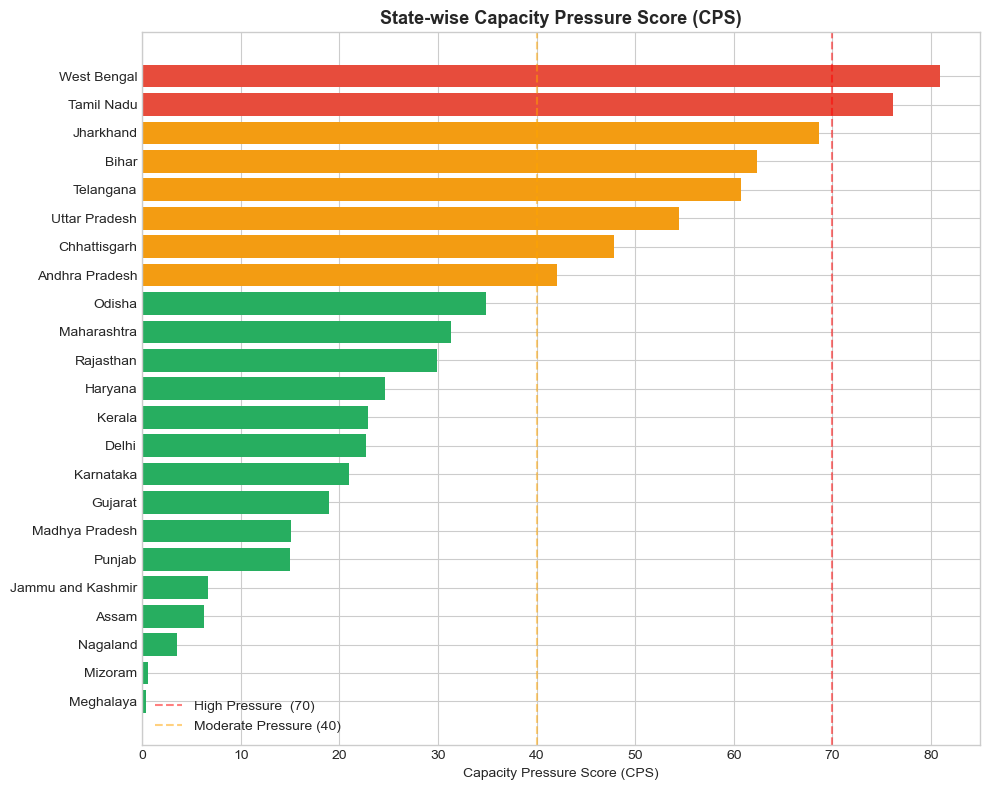

In [11]:
# Sort by CPS
cps_sorted = cps_final.sort_values("CPS", ascending=False)

color_map = {
    "Red":"#e74c3c",
    "Yellow": "#f39c12",
    "Green": "#27ae60"
}

colors = cps_sorted["CPS_Category"].map(color_map)

plt.figure(figsize=(10, 8))
plt.barh(cps_sorted["state"], cps_sorted["CPS"], color=colors)
plt.axvline(70, linestyle="--", color="red", alpha=0.5, label="High Pressure  (70)")
plt.axvline(40, linestyle="--", color="orange", alpha=0.5, label="Moderate Pressure (40)")

plt.xlabel("Capacity Pressure Score (CPS)")
plt.title("State-wise Capacity Pressure Score (CPS)",
    fontsize=13,
    fontweight="bold")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("plot_1_cps_ranking.png", dpi=300)
plt.show()




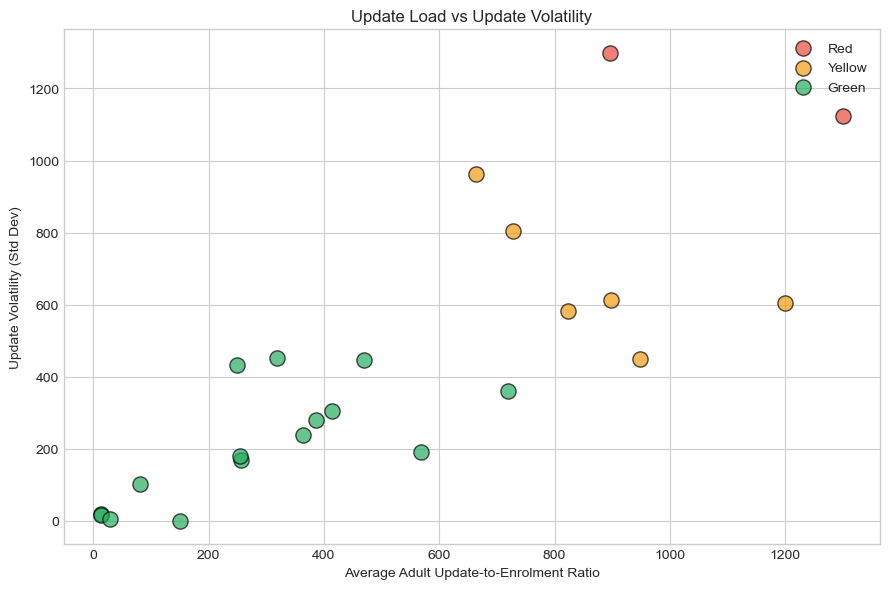

In [12]:
plt.figure(figsize=(9, 6))

for cat, color in color_map.items():
    subset = cps_final[cps_final["CPS_Category"] == cat]
    plt.scatter(
        subset["avg_update_ratio"],
        subset["update_volatility"],
        label=cat,
        color=color,
        s=120,
        edgecolor="black",
        alpha=0.7
    )

plt.xlabel("Average Adult Update-to-Enrolment Ratio")
plt.ylabel("Update Volatility (Std Dev)")
plt.title("Update Load vs Update Volatility")
plt.legend()
plt.tight_layout()

plt.savefig("plot_2_load_vs_volatility.png", dpi=300)
plt.show()




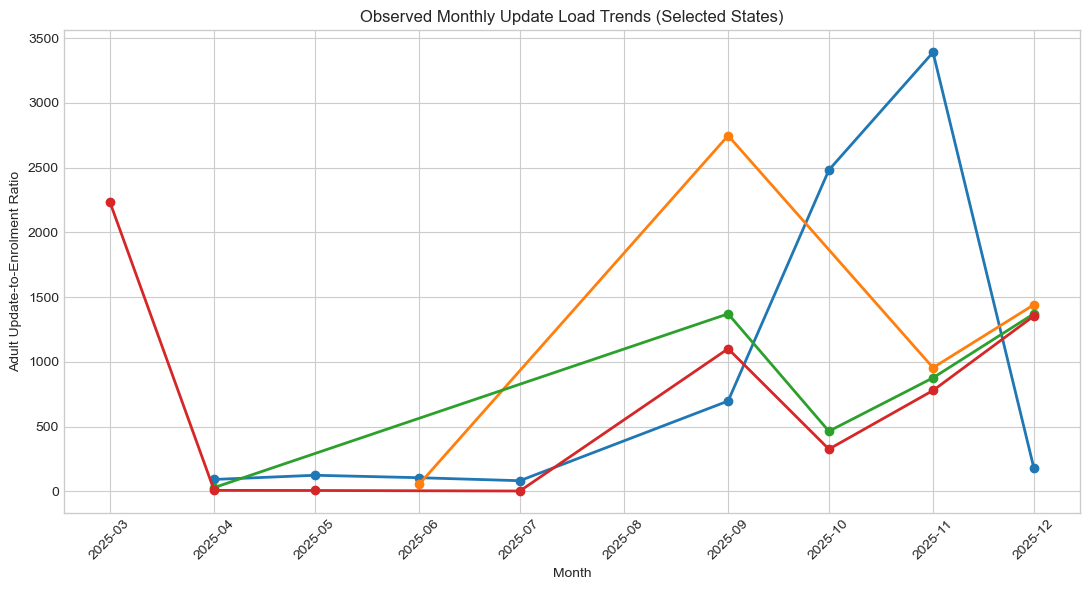

In [14]:

top_states = cps_sorted.head(4)["state"].tolist()

state_month_combined["month"] = pd.PeriodIndex(
    state_month_combined["month"], freq="M"
)
state_month_combined["month_dt"] = state_month_combined["month"].dt.to_timestamp()

plt.figure(figsize=(11, 6))

for state in top_states:
    data = (
        state_month_combined[state_month_combined["state"] == state]
        .sort_values("month_dt")
    )
    plt.plot(
        data["month_dt"],
        data["adult_update_ratio"],
        marker="o",
        linewidth=2,
        label=state
    )

plt.xlabel("Month")
plt.ylabel("Adult Update-to-Enrolment Ratio")
plt.title("Observed Monthly Update Load Trends (Selected States)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("plot_3_monthly_trends.png", dpi=300)
plt.show()




In [15]:
print("Recomputing anomalies from state-month data")

anomalies = []

for state in state_month_combined['state'].unique():
    state_data = state_month_combined[
        state_month_combined['state'] == state
    ].copy()

    if len(state_data) < 3:
        continue 

    mean_ratio = state_data['adult_update_ratio'].mean()
    std_ratio = state_data['adult_update_ratio'].std()

    state_data['z_score'] = (
        (state_data['adult_update_ratio'] - mean_ratio) /
        (std_ratio + 0.01)
    )

    flagged = state_data[state_data['z_score'] > 2]

    for _, row in flagged.iterrows():
        anomalies.append({
            'state': state,
            'month': str(row['month']),
            'adult_update_ratio': row['adult_update_ratio'],
            'z_score': row['z_score']
        })

anomaly_df = pd.DataFrame(anomalies).sort_values(
    'z_score', ascending=False
)

print(f"✓ Anomalies detected: {len(anomaly_df)}")
display(anomaly_df.head(10))


Recomputing anomalies from state-month data
✓ Anomalies detected: 6


,state,month,adult_update_ratio,z_score
1,Gujarat,2025-03,1373.535461,2.608388
5,Uttar Pradesh,2025-03,3030.885757,2.462000
2,Karnataka,2025-03,1356.056277,2.289501
4,Punjab,2025-09,655.204678,2.228844
3,Madhya Pradesh,2025-05,612.554945,2.125197
0,Delhi,2025-12,1032.328467,2.025784


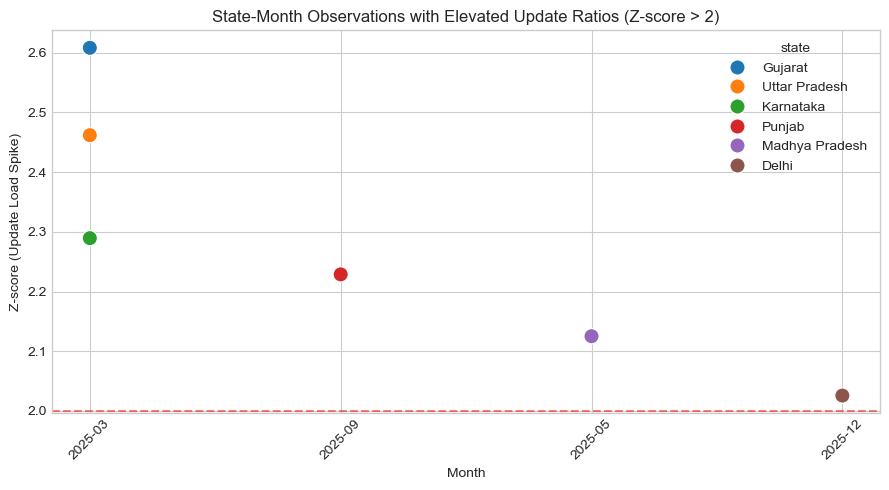

In [18]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=anomaly_df,
    x="month",
    y="z_score",
    hue="state",
    s=120
)

plt.axhline(2, linestyle="--", color="red", alpha=0.5)
plt.xlabel("Month")
plt.ylabel("Z-score (Update Load Spike)")
plt.title("State-Month Observations with Elevated Update Ratios (Z-score > 2)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("plot_4_anomalies.png", dpi=300)
plt.show()


